# sc2ts on simulated pathogens

How well sc2ts recovers recombinants and the overall ARG when the truth is known, for
a range of simulated pathogens. The simulations and scoring are done by the Snakemake
pipeline in `simulations/slim` (see its README); this notebook reads the combined
results it keeps in `simulations/slim/summaries/{pathogen}/`, for every pathogen
found there.

**Simulation.** For each pathogen, SLiM simulates a neutral, haploid Wright-Fisher
population that grows from a single founder to $N$ cases per generation over
`GROWTH_GENS` generations, then stays at that size up to `GENS` generations. The genome
has length $L$ and mutation rate `MU` per site per generation, and a fraction
`EFF_RECOMB` of births have two parents, with a single uniformly placed breakpoint.
Each generation is one sampling date for sc2ts. The parameters of each pathogen are in
the table below, from `simulations/slim/config.yaml`.

**Sampling and inference.** Individuals are sampled from every generation with each of
the pathogen's sampling probabilities $P$, with the samples at a lower $P$ a subset of
those at a higher one. sc2ts is run with $k = 3, 4, 5$ and otherwise the parameters
used for the Viridian ARG, except that its time-traveller filtering is turned off: the
simulated samples have exact dates and no errors, so every sample is added on its own
day. The final ARG is then run through `sc2ts postprocess`, which adds samples
identical to a node already in the ARG ("exact matches") as nodes of their own.

**What counts as a recombinant.** A sample should be inferred to be a recombinant if it
is one itself, *or* if it inherits a recombination from an unsampled ancestor: walking
up its clonal line, it reaches a recombinant before reaching any individual placed in
the inferred ARG. Several samples can share one such recombinant ancestor; once sc2ts
has inferred that recombination in one of them, the rest correctly copy from it with
a single parent. So:

- **precision** is per sample: of the samples sc2ts matched with two parents, the
  fraction expected to be recombinants;
- **recall** is per recombination *event*: the fraction of recombinant ancestors for
  which at least one expected sample was matched with two parents.

Only samples placed in the ARG are scored.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

In [2]:
slim_dir = Path("../simulations/slim")
with open(slim_dir / "config.yaml") as f:
    config = yaml.safe_load(f)

summaries_dir = slim_dir / "summaries"
pathogens = sorted(path.name for path in summaries_dir.iterdir() if path.is_dir())


def load(name):
    return pd.concat(
        [pd.read_csv(summaries_dir / pathogen / f"{name}.csv") for pathogen in pathogens]
    )


# One row per run.
summary = load("summary")
# One row per expected recombination event per run.
events = load("events")
# Samples, placed samples and exact matches per generation per run.
placement = load("placement")

k_values = sorted(summary.k.unique())
p_values = {
    pathogen: sorted(summary[summary.pathogen == pathogen].p.unique())
    for pathogen in pathogens
}
pathogens

['coronavirus']

## Pathogens

In [3]:
rows = []
for pathogen in pathogens:
    params = config["pathogens"][pathogen]
    row = dict(params["slim"])
    row["mutations_per_genome"] = row["L"] * row["MU"]
    row["p_values"] = ", ".join(str(p) for p in params["p_values"])
    rows.append(row)
pd.DataFrame(rows, index=pd.Index(pathogens, name="pathogen"))

,N,GENS,GROWTH_GENS,L,MU,EFF_RECOMB,mutations_per_genome,p_values
pathogen,,,,,,,,
coronavirus,1000,100,20,30000,0.000012,0.01,0.36,"0.02, 0.1"


In [4]:
# k and P are both ordered, so each is one hue stepped light to dark.
k_colors = dict(zip(k_values, ["#86b6ef", "#2a78d6", "#104281"]))
BLUE_RAMP = ["#86b6ef", "#5598e7", "#256abf", "#104281"]


def p_colors(pathogen):
    values = p_values[pathogen]
    steps = np.linspace(0, len(BLUE_RAMP) - 1, len(values)).round().astype(int)
    return dict(zip(values, [BLUE_RAMP[j] for j in steps]))


grid_kwargs = dict(color="0.9", linewidth=0.6)

# The median breakpoint interval in the Viridian ARG, from the paper.
PAPER_MEDIAN_INTERVAL = 2018


def clean_axes(ax):
    ax.yaxis.grid(True, **grid_kwargs)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

## Summary

`exact_matches` is the number of samples added by `sc2ts postprocess`, `held_back` the
number sc2ts never added. `sampled` is the number of samples that are recombinants
themselves, `expected` the number that should be inferred to be recombinants, and
`events` the number of distinct recombinant ancestors behind them.

In [5]:
table = summary.set_index(["pathogen", "p", "k"])[
    [
        "num_samples",
        "num_placed",
        "num_exact_matches",
        "num_held_back",
        "num_sampled_recombinants",
        "num_expected_recombinants",
        "num_events",
        "num_inferred_recombinants",
        "false_positives",
        "precision",
        "events_detected",
        "recall",
        "recall_detectable",
        "breakpoint_in_interval",
    ]
].rename(
    columns=lambda c: c.replace("num_", "").replace("_recombinants", "")
)
table.round(3)

samples  placed  exact_matches  held_back  sampled  \
pathogen    p    k                                                       
coronavirus 0.02 3     1643    1643            125          0       12   
                 4     1643    1643            125          0       12   
                 5     1643    1643            125          0       12   
            0.10 3     8226    8226           2193          0       78   
                 4     8226    8226           2193          0       78   
                 5     8226    8226           2193          0       78   

                    expected  events  inferred  false_positives  precision  \
pathogen    p    k                                                           
coronavirus 0.02 3       310     120        94                7      0.926   
                 4       310     120        82                3      0.963   
                 5       310     120        67                0      1.000   
            0.10 3       639     278       231                8      0.965   
                 4       639     278       194                1      0.995   
                 5       639     278       182                0      1.000   

                    events_detected  recall  recall_detectable  \
pathogen    p    k                                               
coronavirus 0.02 3               83   0.692              0.716   
                 4               76   0.633              0.655   
                 5               64   0.533              0.552   
            0.10 3              206   0.741              0.774   
                 4              179   0.644              0.673   
                 5              168   0.604              0.632   

                    breakpoint_in_interval  
pathogen    p    k                          
coronavirus 0.02 3                   0.901  
                 4                   0.932  
                 5                   0.937  
            0.10 3                   1.000  
                 4                   1.000  
                 5                   1.000

## Precision and recall

Raising $k$ trades recall for precision, as on the real data.

**coronavirus.** Precision is high throughout (0.93 to 1): almost every sample sc2ts
reports as a recombinant really does carry an unrepresented recombination. Recall falls
from about 0.7 at $k = 3$ to 0.5-0.6 at $k = 5$, and is similar at both sampling
densities.

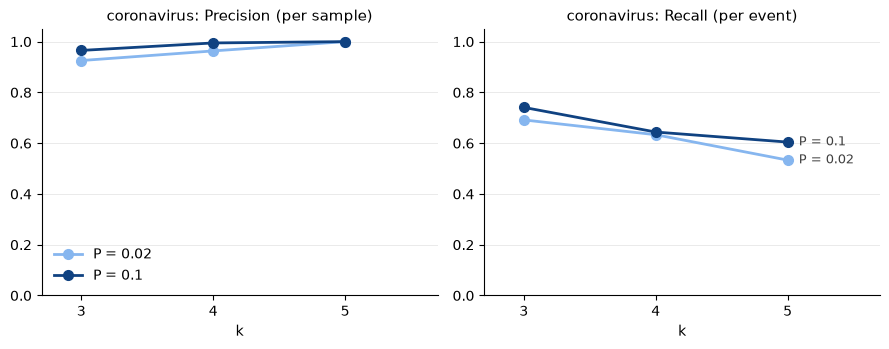

In [6]:
fig, axes = plt.subplots(
    len(pathogens), 2, figsize=(9, 3.6 * len(pathogens)), sharex=True, squeeze=False
)
for row, pathogen in zip(axes, pathogens):
    colors = p_colors(pathogen)
    for ax, column, title in zip(
        row, ["precision", "recall"], ["Precision (per sample)", "Recall (per event)"]
    ):
        for p in p_values[pathogen]:
            df = summary[(summary.pathogen == pathogen) & (summary.p == p)].sort_values("k")
            ax.plot(
                df.k, df[column], marker="o", markersize=7, linewidth=2,
                color=colors[p], label=f"P = {p}",
            )
            # Precision lines sit too close together to label directly.
            if column == "recall":
                ax.annotate(
                    f"P = {p}", xy=(df.k.iloc[-1], df[column].iloc[-1]),
                    xytext=(8, 0), textcoords="offset points", va="center",
                    fontsize=9, color="0.25",
                )
        ax.set_title(f"{pathogen}: {title}", fontsize=11)
        ax.set_xticks(k_values)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(k_values[0] - 0.3, k_values[-1] + 0.7)
        clean_axes(ax)
    row[0].legend(frameon=False, loc="lower left")
for ax in axes[-1]:
    ax.set_xlabel("k")
fig.tight_layout()

## Which events are found

Detectable events (where the recombinant differs from both its parents; the rest leave
no trace), split by whether the recombinant itself was sampled and placed, or is only
seen through its descendants.

**coronavirus.** Most events are only seen through descendants, and sc2ts finds those
at least as well as recombinants that were themselves sampled.

In [7]:
events["kind"] = np.where(events.sampled, "recombinant sampled", "descendants only")
(
    events[events.detectable]
    .groupby(["pathogen", "p", "k", "kind"])
    .detected.agg(["size", "mean"])
    .rename(columns={"size": "events", "mean": "recall"})
    .unstack("kind")
    .round(3)
)

events                               recall  \
kind               descendants only recombinant sampled descendants only   
pathogen    p    k                                                         
coronavirus 0.02 3              104                  12            0.721   
                 4              104                  12            0.663   
                 5              104                  12            0.577   
            0.10 3              191                  75            0.791   
                 4              191                  75            0.696   
                 5              191                  75            0.665   

                                        
kind               recombinant sampled  
pathogen    p    k                      
coronavirus 0.02 3               0.667  
                 4               0.583  
                 5               0.333  
            0.10 3               0.733  
                 4               0.613  
                 5               0.547

## Exact matches

A sample identical to a node already in the ARG is not given a node of its own during
inference, only counted against the node it matches; `sc2ts postprocess` adds these
exact matches as nodes under that node.

**coronavirus.** With about 0.36 mutations per genome per generation, many samples are
identical to a sampled relative: 8% of samples at $P = 0.02$ and 27% at $P = 0.1$,
steady once the population has reached its full size.

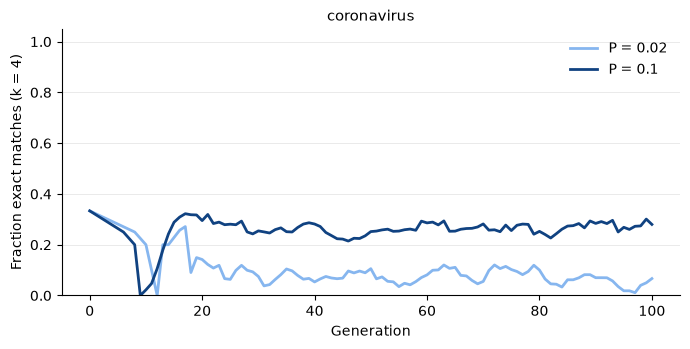

In [8]:
fig, axes = plt.subplots(
    len(pathogens), 1, figsize=(7, 3.6 * len(pathogens)), squeeze=False
)
for ax, pathogen in zip(axes[:, 0], pathogens):
    colors = p_colors(pathogen)
    for p in p_values[pathogen]:
        df = placement[
            (placement.pathogen == pathogen) & (placement.p == p) & (placement.k == 4)
        ].set_index("gen")
        rate = df.num_exact_matches / df.num_samples
        # Smooth over 5 generations: there are few samples per generation at low P.
        smooth = rate.rolling(5, center=True, min_periods=1).mean()
        ax.plot(smooth.index, smooth.values, linewidth=2, color=colors[p], label=f"P = {p}")
    ax.set_title(pathogen, fontsize=11)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fraction exact matches (k = 4)")
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=False)
    clean_axes(ax)
fig.tight_layout()

In [9]:
df = placement[placement.k == 4].groupby(["pathogen", "p"])[
    ["num_samples", "num_exact_matches"]
].sum()
(df.num_exact_matches / df.num_samples).round(3)

pathogen     p   
coronavirus  0.02    0.076
             0.10    0.267
dtype: float64

## Breakpoints

Breakpoint intervals run from the last site supporting the left parent to the first
supporting the right. For events found with a single breakpoint, taking the earliest
sample the event was found in, we compare the interval with the true breakpoint, and
its width with the median in the real Viridian ARG (dashed line, 2,018 bases).

**coronavirus.** The true breakpoint falls in the interval every time at $P = 0.1$ and
90-94% of the time at $P = 0.02$. Interval widths are of the same order as in the real
ARG (medians of about 1,400-1,550 bases at $P = 0.1$ and 1,750 at $P = 0.02$), as
expected with a similar per-genome mutation rate.

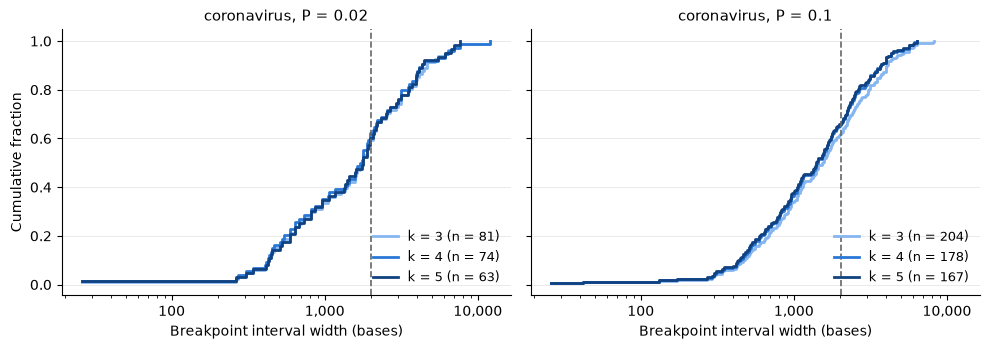

In [10]:
# Events found with a single breakpoint have an interval.
found = events.dropna(subset=["interval_width"])

num_columns = max(len(values) for values in p_values.values())
fig, axes = plt.subplots(
    len(pathogens), num_columns, figsize=(5 * num_columns, 3.6 * len(pathogens)),
    sharex=True, sharey=True, squeeze=False,
)
for row, pathogen in zip(axes, pathogens):
    for ax in row[len(p_values[pathogen]):]:
        ax.set_visible(False)
    for ax, p in zip(row, p_values[pathogen]):
        for k in k_values:
            df = found[(found.pathogen == pathogen) & (found.p == p) & (found.k == k)]
            width = np.sort(df.interval_width.values)
            ax.step(
                width, np.arange(1, len(width) + 1) / len(width), where="post",
                linewidth=2, color=k_colors[k], label=f"k = {k} (n = {len(width)})",
            )
        ax.axvline(PAPER_MEDIAN_INTERVAL, color="0.4", linestyle="--", linewidth=1.2)
        ax.set_title(f"{pathogen}, P = {p}", fontsize=11)
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())
        ax.legend(frameon=False, loc="lower right", fontsize=9)
        clean_axes(ax)
    row[0].set_ylabel("Cumulative fraction")
for ax in axes[-1]:
    ax.set_xlabel("Breakpoint interval width (bases)")
fig.tight_layout()

In [11]:
found.groupby(["pathogen", "p", "k"]).interval_width.median()

pathogen     p     k
coronavirus  0.02  3    1768.0
                   4    1728.0
                   5    1768.0
             0.10  3    1539.0
                   4    1424.5
                   5    1404.0
Name: interval_width, dtype: float64

## ARG accuracy

`tscompare.haplotype_arf(inferred, true)`, over all placed samples. `arf` is the
fraction of the inferred ARG's node span not found in the true ARG, `tpr` the fraction
of the true ARG's span found in the inferred one, and `rmse` the error in log node
times (in generations) of matched nodes.

**coronavirus.** Accuracy is lower at $P = 0.1$ than at $P = 0.02$, which is down to the
exact matches: identical sequences carry no information about how they are related,
and sc2ts places them all directly under the node they match, while the true
genealogy among them is resolved. Leaving the exact matches out of the comparison
(checked for $P = 0.1$, $k = 4$, outside this notebook) gives an ARF of 0.177 and TPR
of 0.620, the same as at $P = 0.02$.

In [12]:
summary.set_index(["pathogen", "p", "k"])[["arf", "tpr", "rmse"]].round(3)

arf    tpr   rmse
pathogen    p    k                     
coronavirus 0.02 3  0.176  0.623  0.102
                 4  0.175  0.626  0.099
                 5  0.179  0.625  0.099
            0.10 3  0.221  0.589  0.056
                 4  0.222  0.588  0.056
                 5  0.223  0.588  0.056

## Notes

- ARF and TPR barely change with $k$. Recombination is rare enough in these
  simulations that the clonal topology dominates the node-span comparison, so these
  measure tree accuracy more than recombinant accuracy, and at high sampling density
  they are dominated by how exact matches are placed.
- **coronavirus.** Turning off sc2ts's time-traveller filtering made the biggest
  difference at low sampling density: with the Viridian settings
  (`hmm_cost_threshold` 7), 39% of samples at $P = 0.02$ were held back and never
  added, and recall there was only 0.41, 0.31 and 0.17 for $k = 3, 4, 5$. With every
  sample added, recall at $P = 0.02$ is close to that at $P = 0.1$. Precision is high
  at every $k$; the few false positives (at most 8 in a run) are worth looking at
  individually.
- One replicate per pathogen so far: no uncertainty estimates yet.